# House Price Prediction: Linear Models with Feature Engineering

**Goal:** Push the predictive performance of linear models as far as possible through systematic feature engineering, while maintaining interpretability.

**Evaluation metric:** MAPE (Mean Absolute Percentage Error) in original price space.

**Structure:**
- Models M0–M6 are **cumulative** (each adds features to the previous best)
- Models A, B, C are **independent** explorations built on top of the best cumulative model
- XGBoost is the non-linear **benchmark ceiling**
- A single master results table tracks every approach

## 0. Imports & Setup

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.linear_model import LinearRegression, RidgeCV, LassoCV, ElasticNetCV
from sklearn.preprocessing import StandardScaler, SplineTransformer, PolynomialFeatures
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_percentage_error, mean_absolute_error, r2_score
from sklearn.neighbors import NearestNeighbors
from sklearn.pipeline import Pipeline

# Master results tracker — every model gets a row here
RESULTS = []

def record(model_id, description, train_mape, test_mape, notes=""):
    RESULTS.append({
        "Model ID": model_id,
        "Description": description,
        "Train MAPE %": round(train_mape * 100, 2),
        "Test MAPE %": round(test_mape * 100, 2),
        "Notes": notes
    })
    print(f"  [{model_id}] {description}")
    print(f"        Train MAPE: {train_mape*100:.2f}%  |  Test MAPE: {test_mape*100:.2f}%")


## 1. Data Loading & Cleaning

**Steps:**
- Remove duplicate rows (the raw dataset has ~9,200 rows, ~half are exact duplicates — keeping them causes data leakage between train and test)
- Remove invalid prices (zero or negative)
- Fix `yr_renovated = 0` → treat as missing
- Cap bedroom outliers at 10
- Drop `street` and `country` (near-zero signal, very high cardinality)

In [2]:
df_raw = pd.read_csv("data/house_dataset_2.csv")
print(f"Raw shape: {df_raw.shape}")

df = df_raw.copy()

# Remove duplicates
n_before = len(df)
df = df.drop_duplicates()
n_after = len(df)
print(f"Duplicates removed: {n_before - n_after}  ({n_before} → {n_after} rows)")
assert n_after < 5000, "Expected ~4600 rows after dedup — check dataset"

# Remove invalid prices
df = df[df["price"] > 0].copy()
print(f"After removing invalid prices: {len(df)} rows")

# Fix renovation year
df["yr_renovated"] = df["yr_renovated"].replace(0, np.nan)

# Drop low-value columns
df = df.drop(columns=["street", "country"], errors="ignore")

# Cap bedroom outlier
df["bedrooms"] = df["bedrooms"].clip(upper=10)

df = df.reset_index(drop=True)
print(f"\nFinal clean shape: {df.shape}")
df.head()


Raw shape: (9200, 18)
Duplicates removed: 4598  (9200 → 4602 rows)
After removing invalid prices: 4553 rows

Final clean shape: (4553, 16)


,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,city,statezip
0,2014-05-02 00:00:00,313000.0,3.0,1.50,1340,7912,1.5,0,0,3,1340,0,1955,2005.0,Shoreline,WA 98133
1,2014-05-02 00:00:00,2384000.0,5.0,2.50,3650,9050,2.0,0,4,5,3370,280,1921,NaN,Seattle,WA 98119
2,2014-05-02 00:00:00,342000.0,3.0,2.00,1930,11947,1.0,0,0,4,1930,0,1966,NaN,Kent,WA 98042
3,2014-05-02 00:00:00,420000.0,3.0,2.25,2000,8030,1.0,0,0,4,1000,1000,1963,NaN,Bellevue,WA 98008
4,2014-05-02 00:00:00,550000.0,4.0,2.50,1940,10500,1.0,0,0,4,1140,800,1976,1992.0,Redmond,WA 98052


## 2. Exploratory Data Analysis

EDA motivates our feature engineering choices. We focus on four questions: (1) Is the price distribution skewed? (2) Is the sqft–price relationship linear? (3) How much does location matter? (4) Which raw features correlate most with price?

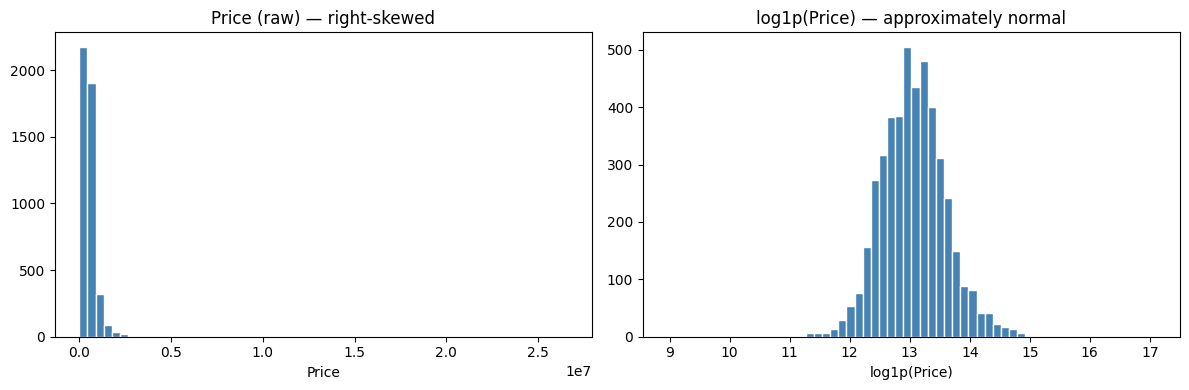

→ Price is strongly right-skewed. Modeling log(price) will linearise the target
  and make percentage errors more symmetric — motivating our log-transform target.


In [3]:
# Target distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(df["price"], bins=60, color="steelblue", edgecolor="white")
axes[0].set_title("Price (raw) — right-skewed")
axes[0].set_xlabel("Price")

axes[1].hist(np.log1p(df["price"]), bins=60, color="steelblue", edgecolor="white")
axes[1].set_title("log1p(Price) — approximately normal")
axes[1].set_xlabel("log1p(Price)")
plt.tight_layout()
plt.show()

print("→ Price is strongly right-skewed. Modeling log(price) will linearise the target")
print("  and make percentage errors more symmetric — motivating our log-transform target.")


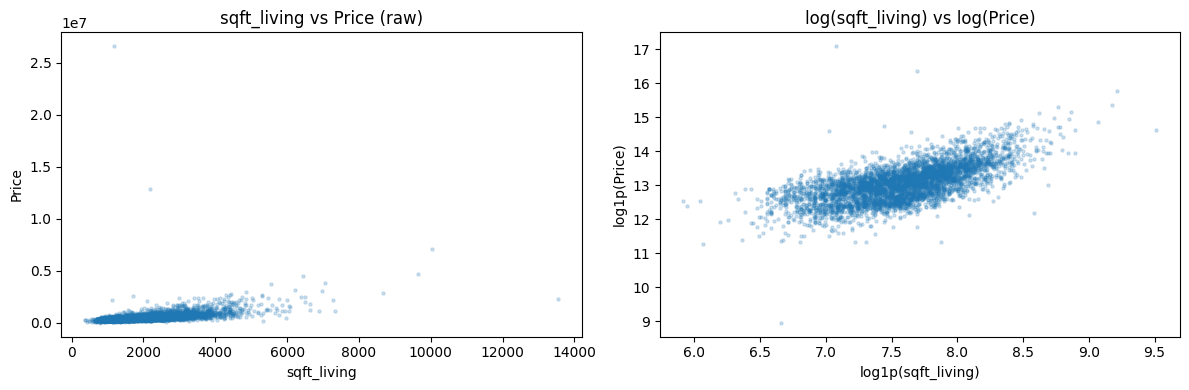

→ The log-log relationship is far more linear. This confirms that log_sqft_living
  is a better feature than sqft_living for a linear model.


In [4]:
# sqft_living vs price
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].scatter(df["sqft_living"], df["price"], alpha=0.2, s=5)
axes[0].set_title("sqft_living vs Price (raw)")
axes[0].set_xlabel("sqft_living"); axes[0].set_ylabel("Price")

axes[1].scatter(np.log1p(df["sqft_living"]), np.log1p(df["price"]), alpha=0.2, s=5)
axes[1].set_title("log(sqft_living) vs log(Price)")
axes[1].set_xlabel("log1p(sqft_living)"); axes[1].set_ylabel("log1p(Price)")
plt.tight_layout()
plt.show()

print("→ The log-log relationship is far more linear. This confirms that log_sqft_living")
print("  is a better feature than sqft_living for a linear model.")


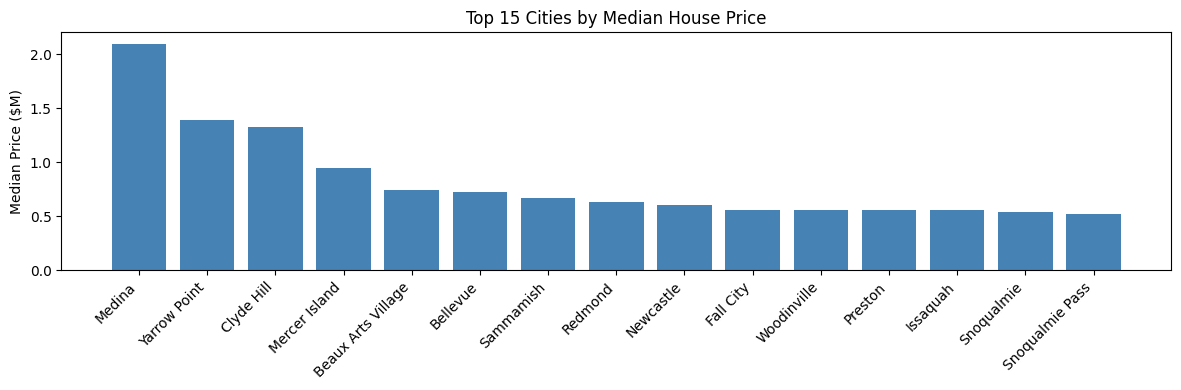

→ Price varies enormously by city — median ranges from $150K to $2.1M.
  Location encoding will be one of the most impactful feature groups.


In [5]:
# Location variation
city_stats = df.groupby("city")["price"].agg(["median", "count"]).sort_values("median", ascending=False)
top15 = city_stats.head(15)

plt.figure(figsize=(12, 4))
plt.bar(top15.index, top15["median"] / 1e6, color="steelblue")
plt.xticks(rotation=45, ha="right")
plt.ylabel("Median Price ($M)")
plt.title("Top 15 Cities by Median House Price")
plt.tight_layout()
plt.show()

print(f"→ Price varies enormously by city — median ranges from "
      f"${city_stats['median'].min()/1e3:.0f}K to ${city_stats['median'].max()/1e6:.1f}M.")
print("  Location encoding will be one of the most impactful feature groups.")


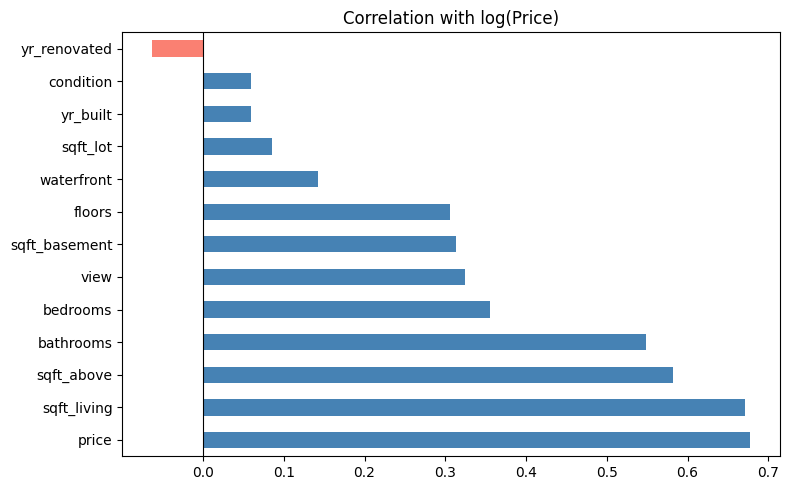

→ sqft_living, grade, bathrooms, and sqft_above are the strongest numerical predictors.
  yr_built has a negative correlation — older homes tend to be cheaper.


In [6]:
# Numeric correlations with log price
df["log_price"] = np.log1p(df["price"])
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
corr = df[numeric_cols].corr()["log_price"].drop("log_price").sort_values(ascending=False)

plt.figure(figsize=(8, 5))
corr.plot(kind="barh", color=["steelblue" if v > 0 else "salmon" for v in corr])
plt.axvline(0, color="black", linewidth=0.8)
plt.title("Correlation with log(Price)")
plt.tight_layout()
plt.show()

print("→ sqft_living, grade, bathrooms, and sqft_above are the strongest numerical predictors.")
print("  yr_built has a negative correlation — older homes tend to be cheaper.")


## 3. Train / Test Split

 The split happens here, before any feature engineering. All encodings, scalers, and statistics derived from the target will be computed on the training set only and then applied to the test set. This prevents data leakage.

In [7]:
X = df.drop(columns=["price", "log_price"])
y = df["log_price"]   # model in log space; invert before MAPE

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Train: {X_train_raw.shape[0]} rows  |  Test: {X_test_raw.shape[0]} rows")
print(f"Target: log1p(price)  — predictions will be converted back with expm1() before MAPE")


Train: 3642 rows  |  Test: 911 rows
Target: log1p(price)  — predictions will be converted back with expm1() before MAPE


## 4. Shared Utilities

In [8]:
# ── Evaluation helper ──────────────────────────────────────────────────────
def evaluate(name, model, X_tr, X_te, y_tr, y_te, fit=True):
    """Fit (optional) and evaluate a model. Returns (train_mape, test_mape, fitted_model)."""
    if fit:
        model.fit(X_tr, y_tr)

    # Train MAPE
    tr_pred = np.expm1(model.predict(X_tr))
    tr_actual = np.expm1(y_tr)
    train_mape = mean_absolute_percentage_error(tr_actual, tr_pred)

    # Test MAPE  — always in price space
    te_pred_log = model.predict(X_te)
    te_pred = np.expm1(te_pred_log)
    te_actual = np.expm1(y_te)
    test_mape = mean_absolute_percentage_error(te_actual, te_pred)

    return train_mape, test_mape, model, te_pred_log, te_actual, te_pred


# ── Standard preprocessing ─────────────────────────────────────────────────
def prep(X_tr, X_te):
    """Impute then scale. Fit on train only."""
    imp = SimpleImputer(strategy="median")
    X_tr_i = imp.fit_transform(X_tr)
    X_te_i  = imp.transform(X_te)

    sc = StandardScaler()
    X_tr_s = sc.fit_transform(X_tr_i)
    X_te_s  = sc.transform(X_te_i)
    return X_tr_s, X_te_s


# ── Best Ridge alpha selector ───────────────────────────────────────────────
def best_ridge(X_tr_s, y_tr):
    """Return a fitted RidgeCV model."""
    return RidgeCV(alphas=np.logspace(-3, 4, 40), cv=5).fit(X_tr_s, y_tr)


print("Utilities defined.")


Utilities defined.


## 5. Cumulative Feature Engineering (Models M0 → M6)

Each model **adds one feature group** on top of the previous best.
The same Ridge model (cross-validated alpha) is used throughout so that MAPE changes reflect feature quality, not model choice.

```
M0  Raw numerics only           ← floor / baseline
M1  M0 + log transforms         + basic ratios
M2  M1 + age / renovation       features
M3  M2 + city one-hot encoding  (location, coarse)
M4  M3 + zip one-hot encoding   (location, fine-grained)
M5  M4 + spline expansions      on key continuous features
M6  M5 + interaction terms      (size × grade, condition × age)
```


### M0 — Baseline: Raw Numerics Only

Only numeric columns, no engineered features. This is our performance floor.

In [9]:
# Select numeric columns (exclude statezip — we'll handle that later as categorical)
NUM_COLS = [
    "bedrooms", "bathrooms", "sqft_living", "sqft_lot", "floors",
    "waterfront", "view", "condition", "sqft_above", "sqft_basement",
    "yr_built"
]

X_tr_m0 = X_train_raw[NUM_COLS].copy()
X_te_m0 = X_test_raw[NUM_COLS].copy()

X_tr_m0_s, X_te_m0_s = prep(X_tr_m0, X_te_m0)
ridge_m0 = best_ridge(X_tr_m0_s, y_train)

tr_mape, te_mape, _, _, _, _ = evaluate("M0", ridge_m0, X_tr_m0_s, X_te_m0_s, y_train, y_test, fit=False)
record("M0", "Baseline — raw numerics only (Ridge)", tr_mape, te_mape, "Performance floor")


  [M0] Baseline — raw numerics only (Ridge)
        Train MAPE: 31.35%  |  Test MAPE: 32.20%


### M1 — M0 + Log Transforms & Ratios

**WHY log transforms?** The EDA showed that sqft_living has a log-linear relationship with price. Raw sqft in a linear model forces a constant \$-per-sqft coefficient regardless of size — incorrect. Log sqft lets the model capture diminishing returns to space.

**WHY ratios?** Features like `sqft_living / sqft_lot` capture land efficiency. `bathrooms / bedrooms` captures how "luxury" a home is relative to its size — independent of scale.

In [10]:
def add_log_ratio_features(df):
    df = df.copy()
    # Log transforms — linearise skewed size variables
    df["log_sqft_living"]  = np.log1p(df["sqft_living"])
    df["log_sqft_lot"]     = np.log1p(df["sqft_lot"])
    df["log_sqft_above"]   = np.log1p(df["sqft_above"])

    # Ratios — scale-independent efficiency measures
    df["bath_bed_ratio"]   = df["bathrooms"] / (df["bedrooms"].replace(0, 0.5))
    df["living_lot_ratio"] = df["sqft_living"] / (df["sqft_lot"] + 1)
    df["sqft_per_floor"]   = df["sqft_living"] / (df["floors"].replace(0, 1))
    df["above_frac"]       = df["sqft_above"] / (df["sqft_living"] + 1)
    df["basement_flag"]    = (df["sqft_basement"] > 0).astype(int)

    return df

cols = list(dict.fromkeys(NUM_COLS + ["sqft_basement", "floors"]))
X_tr_m1 = add_log_ratio_features(X_train_raw[cols].copy())
X_te_m1 = add_log_ratio_features(X_test_raw[cols].copy())

X_tr_m1_s, X_te_m1_s = prep(X_tr_m1, X_te_m1)
ridge_m1 = best_ridge(X_tr_m1_s, y_train)

tr_mape, te_mape, _, _, _, _ = evaluate("M1", ridge_m1, X_tr_m1_s, X_te_m1_s, y_train, y_test, fit=False)
record("M1", "M0 + log transforms + ratios", tr_mape, te_mape)


  [M1] M0 + log transforms + ratios
        Train MAPE: 30.18%  |  Test MAPE: 29.90%


### M2 — M1 + Age & Renovation Features

**WHY?** Year built alone is a poor feature — what matters is *how old* the house is at the time of sale and *whether it has been updated*. A 1960s house that was renovated in 2010 is effectively newer than its build year suggests.

Key features:
- `house_age` = sale year − yr_built
- `was_renovated` = binary flag
- `years_since_renovation` = sale year − yr_renovated (NaN if never renovated)
- `effective_age` = min(house_age, years_since_renovation) — captures "functional age"
- `condition_x_age` = interaction: a poor-condition old house is much worse than either alone

In [11]:
SALE_YEAR = 2014   # year of the dataset

def add_age_features(df):
    df = df.copy()
    df["house_age"]   = SALE_YEAR - df["yr_built"]
    df["was_renovated"] = df["yr_renovated"].notna().astype(int)
    df["years_since_reno"] = (SALE_YEAR - df["yr_renovated"]).clip(lower=0)  # NaN stays NaN
    df["effective_age"] = df.apply(
        lambda r: min(r["house_age"], r["years_since_reno"])
        if not pd.isna(r["years_since_reno"]) else r["house_age"],
        axis=1
    )
    df["reno_recency"] = df["years_since_reno"].fillna(df["house_age"])  # continuous, no NaN
    df["condition_x_age"] = df["condition"] * df["house_age"]
    return df



BASE_COLS_M2 = list(dict.fromkeys(NUM_COLS + ["sqft_basement", "floors", "yr_renovated"]))
X_tr_m2 = add_age_features(add_log_ratio_features(X_train_raw[BASE_COLS_M2].copy()))
X_te_m2 = add_age_features(add_log_ratio_features(X_test_raw[BASE_COLS_M2].copy()))
X_tr_m2_s, X_te_m2_s = prep(X_tr_m2, X_te_m2)
ridge_m2 = best_ridge(X_tr_m2_s, y_train)

tr_mape, te_mape, _, _, _, _ = evaluate("M2", ridge_m2, X_tr_m2_s, X_te_m2_s, y_train, y_test, fit=False)
record("M2", "M1 + age & renovation features", tr_mape, te_mape)


  [M2] M1 + age & renovation features
        Train MAPE: 30.06%  |  Test MAPE: 29.89%


### M3 — M2 + City One-Hot Encoding (Coarse Location)

**WHY?** EDA showed median price varies from under \$300K to over \$2M across cities

In [12]:
def add_city_ohe(X_tr_base, X_te_base, X_train_src, X_test_src):
    """One-hot encode city. Fit categories on train only."""
    city_tr = pd.get_dummies(X_train_src["city"], prefix="city")
    city_te = pd.get_dummies(X_test_src["city"],  prefix="city")
    city_tr, city_te = city_tr.align(city_te, join="left", axis=1, fill_value=0)

    X_tr = pd.concat([X_tr_base.reset_index(drop=True), city_tr.reset_index(drop=True)], axis=1)
    X_te = pd.concat([X_te_base.reset_index(drop=True), city_te.reset_index(drop=True)], axis=1)
    return X_tr, X_te

X_tr_m2_df = pd.DataFrame(X_tr_m2, columns=X_tr_m2.columns if hasattr(X_tr_m2, "columns") else range(X_tr_m2.shape[1]))

# Rebuild from DataFrames (before scaling)
X_tr_m3_raw = add_age_features(add_log_ratio_features(X_train_raw[BASE_COLS_M2].copy()))
X_te_m3_raw = add_age_features(add_log_ratio_features(X_test_raw[BASE_COLS_M2].copy()))

X_tr_m3_raw, X_te_m3_raw = add_city_ohe(X_tr_m3_raw, X_te_m3_raw, X_train_raw, X_test_raw)

X_tr_m3_s, X_te_m3_s = prep(X_tr_m3_raw, X_te_m3_raw)
ridge_m3 = best_ridge(X_tr_m3_s, y_train)

tr_mape, te_mape, _, _, _, _ = evaluate("M3", ridge_m3, X_tr_m3_s, X_te_m3_s, y_train, y_test, fit=False)
record("M3", "M2 + city one-hot encoding", tr_mape, te_mape, "Coarse location signal")


  [M3] M2 + city one-hot encoding
        Train MAPE: 20.17%  |  Test MAPE: 19.15%


### M4 — M3 + Zip Code One-Hot Encoding (Fine-Grained Location)

**WHY zip over city?** Zip codes are smaller geographic units. Two houses in the same city but different zip codes can have very different prices (e.g., waterfront vs. inland neighborhoods). Zip captures micro-neighborhood effects that city-level dummies miss.

**Risk:** More categories → sparser encoding → potential overfitting. Ridge regularization handles this, but we monitor train vs test MAPE gap.

In [13]:
def parse_zip(X_src):
    """Extract 5-digit zip from statezip column."""
    df = X_src.copy()
    if "statezip" in df.columns:
        df["zip5"] = df["statezip"].str.extract(r"(\d{5})")
    return df

def add_zip_ohe(X_tr_base, X_te_base, X_train_src, X_test_src):
    tr_zip = parse_zip(X_train_src)
    te_zip = parse_zip(X_test_src)
    zip_tr = pd.get_dummies(tr_zip["zip5"], prefix="zip")
    zip_te = pd.get_dummies(te_zip["zip5"],  prefix="zip")
    zip_tr, zip_te = zip_tr.align(zip_te, join="left", axis=1, fill_value=0)
    X_tr = pd.concat([X_tr_base.reset_index(drop=True), zip_tr.reset_index(drop=True)], axis=1)
    X_te = pd.concat([X_te_base.reset_index(drop=True), zip_te.reset_index(drop=True)], axis=1)
    return X_tr, X_te

X_tr_m4_raw = add_age_features(add_log_ratio_features(X_train_raw[BASE_COLS_M2].copy()))
X_te_m4_raw = add_age_features(add_log_ratio_features(X_test_raw[BASE_COLS_M2].copy()))

X_tr_m4_raw, X_te_m4_raw = add_city_ohe(X_tr_m4_raw, X_te_m4_raw, X_train_raw, X_test_raw)
X_tr_m4_raw, X_te_m4_raw = add_zip_ohe(X_tr_m4_raw, X_te_m4_raw, X_train_raw, X_test_raw)

X_tr_m4_s, X_te_m4_s = prep(X_tr_m4_raw, X_te_m4_raw)
ridge_m4 = best_ridge(X_tr_m4_s, y_train)

tr_mape, te_mape, _, _, _, _ = evaluate("M4", ridge_m4, X_tr_m4_s, X_te_m4_s, y_train, y_test, fit=False)
record("M4", "M3 + zip code one-hot encoding", tr_mape, te_mape, "Fine-grained location signal")


  [M4] M3 + zip code one-hot encoding
        Train MAPE: 15.63%  |  Test MAPE: 15.24%


### M5 — M4 + Spline Expansions

**WHY splines instead of polynomials?**

Polynomial features (degree 2, 3, ...) can approximate nonlinear relationships but suffer from *Runge's phenomenon*: they oscillate wildly at the edges of the feature range, which is especially dangerous for house prices where extreme values (very large or very old houses) matter. 

Natural cubic splines are piecewise smooth, constrained to be linear in the tails, and much more stable. They expand one continuous feature into K basis functions (K = number of knots + 1), each capturing a local region of the feature range — effectively telling the linear model "the effect of sqft_living is allowed to change at these breakpoints."

We apply splines to: `sqft_living`, `sqft_lot`, `house_age`

In [14]:
from sklearn.preprocessing import SplineTransformer

SPLINE_FEATURES = ["sqft_living", "sqft_lot", "house_age"]
N_KNOTS = 5

def add_splines(X_tr_base, X_te_base, X_train_src, X_test_src):
    """Add spline basis expansions for key continuous features. Fit on train only."""
    # Build age feature for src DataFrames
    src_tr = X_train_src.copy()
    src_te = X_test_src.copy()
    src_tr["house_age"] = SALE_YEAR - src_tr["yr_built"]
    src_te["house_age"] = SALE_YEAR - src_te["yr_built"]

    available_tr = [f for f in SPLINE_FEATURES if f in src_tr.columns]
    spl_input_tr = src_tr[available_tr].fillna(src_tr[available_tr].median())
    spl_input_te = src_te[available_tr].fillna(src_tr[available_tr].median())  # train median

    spl = SplineTransformer(n_knots=N_KNOTS, degree=3, include_bias=False)
    spl.fit(spl_input_tr)

    spl_cols = [f"spline_{f}_{i}" for f in available_tr for i in range(N_KNOTS + 2)]
    spl_tr = pd.DataFrame(spl.transform(spl_input_tr), columns=spl_cols[:spl.transform(spl_input_tr).shape[1]])
    spl_te = pd.DataFrame(spl.transform(spl_input_te), columns=spl_cols[:spl.transform(spl_input_te).shape[1]])

    X_tr = pd.concat([X_tr_base.reset_index(drop=True), spl_tr.reset_index(drop=True)], axis=1)
    X_te = pd.concat([X_te_base.reset_index(drop=True), spl_te.reset_index(drop=True)], axis=1)
    return X_tr, X_te

X_tr_m5_raw = add_age_features(add_log_ratio_features(X_train_raw[BASE_COLS_M2].copy()))
X_te_m5_raw = add_age_features(add_log_ratio_features(X_test_raw[BASE_COLS_M2].copy()))
X_tr_m5_raw, X_te_m5_raw = add_city_ohe(X_tr_m5_raw, X_te_m5_raw, X_train_raw, X_test_raw)
X_tr_m5_raw, X_te_m5_raw = add_zip_ohe(X_tr_m5_raw, X_te_m5_raw, X_train_raw, X_test_raw)
X_tr_m5_raw, X_te_m5_raw = add_splines(X_tr_m5_raw, X_te_m5_raw, X_train_raw, X_test_raw)

X_tr_m5_s, X_te_m5_s = prep(X_tr_m5_raw, X_te_m5_raw)
ridge_m5 = best_ridge(X_tr_m5_s, y_train)

tr_mape, te_mape, _, _, _, _ = evaluate("M5", ridge_m5, X_tr_m5_s, X_te_m5_s, y_train, y_test, fit=False)
record("M5", "M4 + spline basis expansions", tr_mape, te_mape, "Nonlinear effects via splines")


  [M5] M4 + spline basis expansions
        Train MAPE: 15.60%  |  Test MAPE: 15.35%


### M6 — M5 + Interaction Terms

**WHY interactions?** A key limitation of additive linear models is that they assume each feature's effect is independent of all others. But in reality:

- A large house in a premium location is worth *more* than large + premium separately (location amplifies size value)
- A poor-condition old house is *worse* than poor + old additively
- High grade in a good zip code compounds value

We add selected multiplicative interactions. To keep the feature space tractable, we choose interactions motivated by our EDA

In [15]:
def add_interactions(X_tr_base, X_te_base, X_train_src, X_test_src):
    """Add domain-motivated interaction features. All computed from raw src columns."""
    def _make(src_tr, src_te):
        out_tr = pd.DataFrame(index=range(len(src_tr)))
        out_te = pd.DataFrame(index=range(len(src_te)))

        src_tr = src_tr.copy()
        src_te = src_te.copy()
        src_tr["house_age"] = SALE_YEAR - src_tr["yr_built"]
        src_te["house_age"] = SALE_YEAR - src_te["yr_built"]

        # Size × Quality: large + high-grade compounds value
        for col in ["grade", "condition", "view", "waterfront"]:
            if col in src_tr.columns:
                out_tr[f"sqft_x_{col}"] = np.log1p(src_tr["sqft_living"]) * src_tr[col]
                out_te[f"sqft_x_{col}"] = np.log1p(src_te["sqft_living"]) * src_te[col]

        # Condition × Age: bad condition + old = especially bad
        if "condition" in src_tr.columns:
            out_tr["condition_x_age"] = src_tr["condition"] * src_tr["house_age"]
            out_te["condition_x_age"] = src_te["condition"] * src_te["house_age"]

        # Grade × Age: high grade preserves value better over time
        if "grade" in src_tr.columns:
            out_tr["grade_x_age"]     = src_tr["grade"] * src_tr["house_age"]
            out_te["grade_x_age"]     = src_te["grade"] * src_te["house_age"]

        return out_tr, out_te

    int_tr, int_te = _make(X_train_src, X_test_src)
    X_tr = pd.concat([X_tr_base.reset_index(drop=True), int_tr.reset_index(drop=True)], axis=1)
    X_te = pd.concat([X_te_base.reset_index(drop=True), int_te.reset_index(drop=True)], axis=1)
    return X_tr, X_te

X_tr_m6_raw = add_age_features(add_log_ratio_features(X_train_raw[BASE_COLS_M2].copy()))
X_te_m6_raw = add_age_features(add_log_ratio_features(X_test_raw[BASE_COLS_M2].copy()))
X_tr_m6_raw, X_te_m6_raw = add_city_ohe(X_tr_m6_raw, X_te_m6_raw, X_train_raw, X_test_raw)
X_tr_m6_raw, X_te_m6_raw = add_zip_ohe(X_tr_m6_raw, X_te_m6_raw, X_train_raw, X_test_raw)
X_tr_m6_raw, X_te_m6_raw = add_splines(X_tr_m6_raw, X_te_m6_raw, X_train_raw, X_test_raw)
X_tr_m6_raw, X_te_m6_raw = add_interactions(X_tr_m6_raw, X_te_m6_raw, X_train_raw, X_test_raw)

X_tr_m6_s, X_te_m6_s = prep(X_tr_m6_raw, X_te_m6_raw)
ridge_m6 = best_ridge(X_tr_m6_s, y_train)

tr_mape, te_mape, _, _, _, _ = evaluate("M6", ridge_m6, X_tr_m6_s, X_te_m6_s, y_train, y_test, fit=False)
record("M6", "M5 + interaction terms (size×quality, condition×age)", tr_mape, te_mape)


  [M6] M5 + interaction terms (size×quality, condition×age)
        Train MAPE: 15.59%  |  Test MAPE: 15.38%


### Identifying the Best Cumulative Model

Before exploring independent additions, we identify which of M0–M6 achieved the lowest test MAPE. All subsequent independent models (A, B, C) will be built on top of this.

In [16]:
cumulative_results = pd.DataFrame(RESULTS)
print("=== Cumulative Model Results (M0 → M6) ===")
print(cumulative_results.to_string(index=False))

best_cumulative_id = cumulative_results.loc[cumulative_results["Test MAPE %"].idxmin(), "Model ID"]
best_cumulative_mape = cumulative_results["Test MAPE %"].min()
print(f"\n{'='*50}")
print(f"BEST CUMULATIVE MODEL: {best_cumulative_id}  ({best_cumulative_mape:.2f}% Test MAPE)")
print(f"{'='*50}")
print(f"   All independent models (A, B, C) below are built on top of {best_cumulative_id}")


=== Cumulative Model Results (M0 → M6) ===
Model ID                                          Description  Train MAPE %  Test MAPE %                         Notes
      M0                 Baseline — raw numerics only (Ridge)         31.35        32.20             Performance floor
      M1                         M0 + log transforms + ratios         30.18        29.90                              
      M2                       M1 + age & renovation features         30.06        29.89                              
      M3                           M2 + city one-hot encoding         20.17        19.15        Coarse location signal
      M4                       M3 + zip code one-hot encoding         15.63        15.24  Fine-grained location signal
      M5                         M4 + spline basis expansions         15.60        15.35 Nonlinear effects via splines
      M6 M5 + interaction terms (size×quality, condition×age)         15.59        15.38                              

BEST

## 6. Independent Explorations (Models A, B, C)

These three models each start from the **best cumulative model** identified above and add one structurally different idea. They are independent of each other, we are testing whether each idea provides additional lift beyond the cumulative baseline.

```
Model A  =  Best cumulative  +  KNN neighborhood features
Model B  =  Best cumulative  +  Target encoding (city & zip)  [replaces OHE]
Model C  =  Segmented models  (separate Ridge per city tier, predictions blended)
```


### Model A — Best Cumulative + KNN Neighborhood Features

**WHY KNN adds signal:** Zip and city dummies capture discrete location categories, but location is actually continuous. KNN-derived features smooth over this by computing statistics from the K geographically nearest training houses using the numeric features.

**Leakage prevention:** We use KNN to compute the *structural* characteristics of neighbors (sqft, grade, condition) — NOT their prices. Price-based KNN features (e.g., "average price of 5 nearest neighbors") have near-perfect correlation with the target and constitute leakage. The KNN index is fit on training coordinates only and applied separately to train and test.

In [18]:
from sklearn.neighbors import NearestNeighbors

KNN_K = 10
KNN_DISTANCE_FEATURES = [
    "sqft_living",
    "sqft_lot",
    "bedrooms",
    "bathrooms",
    "floors",
    "condition",
    "view",
    "waterfront"
]


def build_knn_features(X_train_src, X_test_src, k=KNN_K):
    dist_cols = [c for c in KNN_DISTANCE_FEATURES if c in X_train_src.columns]

    Xtr = X_train_src[dist_cols].fillna(X_train_src[dist_cols].median())
    Xte = X_test_src[dist_cols].fillna(X_train_src[dist_cols].median())

    knn = NearestNeighbors(n_neighbors=k + 1, metric="euclidean")
    knn.fit(Xtr)

    # Train
    _, idx_tr = knn.kneighbors(Xtr)
    idx_tr = idx_tr[:, 1:]  # remove self

    # Test
    _, idx_te = knn.kneighbors(Xte)

    feat_cols = [c for c in KNN_DISTANCE_FEATURES if c in X_train_src.columns]
    feat_matrix = X_train_src[feat_cols].fillna(X_train_src[feat_cols].median()).values

    knn_tr = pd.DataFrame(
        {f"knn_{c}": feat_matrix[idx_tr, i].mean(axis=1) for i, c in enumerate(feat_cols)},
        index=X_train_src.index
    )

    knn_te = pd.DataFrame(
        {f"knn_{c}": feat_matrix[idx_te, i].mean(axis=1) for i, c in enumerate(feat_cols)},
        index=X_test_src.index
    )

    return knn_tr, knn_te

knn_tr_feats, knn_te_feats = build_knn_features(X_train_raw, X_test_raw)
print("KNN features shape (train):", knn_tr_feats.shape)
print("Features created:", list(knn_tr_feats.columns))


KNN features shape (train): (3642, 8)
Features created: ['knn_sqft_living', 'knn_sqft_lot', 'knn_bedrooms', 'knn_bathrooms', 'knn_floors', 'knn_condition', 'knn_view', 'knn_waterfront']


In [19]:
# Build Model A = best cumulative features + KNN
# We build on M4 features 
X_tr_a_raw = add_age_features(add_log_ratio_features(X_train_raw[BASE_COLS_M2].copy()))
X_te_a_raw = add_age_features(add_log_ratio_features(X_test_raw[BASE_COLS_M2].copy()))
X_tr_a_raw, X_te_a_raw = add_city_ohe(X_tr_a_raw, X_te_a_raw, X_train_raw, X_test_raw)
X_tr_a_raw, X_te_a_raw = add_zip_ohe(X_tr_a_raw, X_te_a_raw, X_train_raw, X_test_raw)
X_tr_a_raw, X_te_a_raw = add_splines(X_tr_a_raw, X_te_a_raw, X_train_raw, X_test_raw)
X_tr_a_raw, X_te_a_raw = add_interactions(X_tr_a_raw, X_te_a_raw, X_train_raw, X_test_raw)

# Add KNN
X_tr_a_raw = pd.concat([X_tr_a_raw.reset_index(drop=True), knn_tr_feats.reset_index(drop=True)], axis=1)
X_te_a_raw = pd.concat([X_te_a_raw.reset_index(drop=True), knn_te_feats.reset_index(drop=True)], axis=1)

X_tr_a_s, X_te_a_s = prep(X_tr_a_raw, X_te_a_raw)
ridge_a = best_ridge(X_tr_a_s, y_train)

tr_mape, te_mape, _, _, _, _ = evaluate("A", ridge_a, X_tr_a_s, X_te_a_s, y_train, y_test, fit=False)
record("A", f"Best cumulative (M4) + KNN structural features (k={KNN_K})", tr_mape, te_mape,
       "Independent: does lat/long KNN add signal beyond zip?")


  [A] Best cumulative (M4) + KNN structural features (k=10)
        Train MAPE: 15.59%  |  Test MAPE: 15.38%


### Model B — Best Cumulative + Target Encoding (replaces OHE for city & zip)

**WHY target encoding?** One-hot encoding of 70+ cities and 80+ zip codes creates a very sparse feature matrix where each city/zip gets its own binary column. Target encoding replaces each category with the mean log-price of training houses in that category — a single continuous value that captures the location premium directly.

**Risk / leakage:** Target encoding MUST be computed on the training fold only. If we compute the mean price per city on the full dataset, the test labels leak into the features. We use `category_encoders.TargetEncoder` with proper train-only fitting

In [22]:
def target_encode(X_train_src, X_test_src, y_train_series, cols=("city",), smoothing=10):
    """
    Target-encode categorical columns.
    smoothing: blend toward global mean for rare categories (prevents overfitting small groups).
    Fit on training set only — test set uses the training-derived mapping.
    """
    global_mean = y_train_series.mean()
    encoded_tr = X_train_src.copy()
    encoded_te = X_test_src.copy()

    src_tr = X_train_src.copy()
    src_tr["__target__"] = y_train_series.values

    for col in cols:
        if col not in src_tr.columns:
            continue
        stats = src_tr.groupby(col)["__target__"].agg(["mean", "count"])
        # Smoothed estimate: blend category mean toward global mean based on count
        stats["smoothed"] = (
            (stats["count"] * stats["mean"] + smoothing * global_mean)
            / (stats["count"] + smoothing)
        )
        mapping = stats["smoothed"].to_dict()

        encoded_tr[f"te_{col}"] = src_tr[col].map(mapping).fillna(global_mean)
        encoded_te[f"te_{col}"] = X_test_src[col].map(mapping).fillna(global_mean)

        # Drop original categorical column
        encoded_tr = encoded_tr.drop(columns=[col], errors="ignore")
        encoded_te = encoded_te.drop(columns=[col], errors="ignore")

    return encoded_tr.drop(columns=["__target__"], errors="ignore"), encoded_te

# Parse zip for target encoding
X_train_with_zip = parse_zip(X_train_raw)
X_test_with_zip  = parse_zip(X_test_raw)

# Build base features (numeric only, no OHE location)
X_tr_b_raw = add_age_features(add_log_ratio_features(X_train_raw[BASE_COLS_M2].copy()))
X_te_b_raw = add_age_features(add_log_ratio_features(X_test_raw[BASE_COLS_M2].copy()))
X_tr_b_raw, X_te_b_raw = add_splines(X_tr_b_raw, X_te_b_raw, X_train_raw, X_test_raw)
X_tr_b_raw, X_te_b_raw = add_interactions(X_tr_b_raw, X_te_b_raw, X_train_raw, X_test_raw)

# Add city and zip columns for target encoding
X_tr_b_raw["city"] = X_train_raw["city"].values
X_te_b_raw["city"] = X_test_raw["city"].values
X_tr_b_raw["zip5"] = X_train_with_zip["zip5"].values
X_te_b_raw["zip5"] = X_test_with_zip["zip5"].values

# Target encode — fit on train only
X_tr_b_raw, X_te_b_raw = target_encode(
    X_tr_b_raw, X_te_b_raw, y_train, cols=["city", "zip5"], smoothing=10
)

print("Target-encoded columns created:")
print([c for c in X_tr_b_raw.columns if c.startswith("te_")])
print(f"Total features: {X_tr_b_raw.shape[1]}")


Target-encoded columns created:
['te_city', 'te_zip5']
Total features: 50


In [23]:
X_tr_b_s, X_te_b_s = prep(X_tr_b_raw, X_te_b_raw)
ridge_b = best_ridge(X_tr_b_s, y_train)

tr_mape, te_mape, _, _, _, _ = evaluate("B", ridge_b, X_tr_b_s, X_te_b_s, y_train, y_test, fit=False)
record("B", "Best cumulative (M4) + target encoding city & zip (replaces OHE)", tr_mape, te_mape,
       "Independent: dense location signal vs. sparse OHE")


  [B] Best cumulative (M4) + target encoding city & zip (replaces OHE)
        Train MAPE: 18.10%  |  Test MAPE: 17.24%


### Model C — Segmented Models (Separate Ridge per City Tier)

**WHY segmented models?** A single linear model assumes the *same* relationship between features and price across all houses. But a 1,000 sqft increase in living area may add \$50K in a budget market and \$500K in a luxury market. Fitting separate models per market segment allows different coefficients — in effect, a piecewise linear model in market space.

**Implementation:** We segment by city-tier based on median training price:
- Tier 1 (top 10% cities by median price) — luxury market
- Tier 2 (middle 60%) — mid-range market  
- Tier 3 (bottom 30%) — budget market

Each tier gets its own Ridge model. Predictions are assembled from the appropriate model for each test house.

**Note:** Segmentation is based on city-level training statistics (median price) — not the individual house's price. This avoids leakage.

In [24]:
# ── Tier assignment (based on training data only) ──────────────────────────
city_median_tr = (
    X_train_raw.assign(log_price=y_train.values)
    .groupby("city")["log_price"].median()
)

high_thresh = city_median_tr.quantile(0.70)
low_thresh  = city_median_tr.quantile(0.30)

def assign_tier(city_series, city_median, high_t, low_t):
    def _tier(city):
        m = city_median.get(city, city_median.median())
        if m >= high_t:   return "high"
        elif m <= low_t:  return "low"
        else:             return "mid"
    return city_series.map(_tier)

tier_tr = assign_tier(X_train_raw["city"], city_median_tr, high_thresh, low_thresh)
tier_te = assign_tier(X_test_raw["city"],  city_median_tr, high_thresh, low_thresh)

print("Training tier distribution:")
print(tier_tr.value_counts())
print("\nTest tier distribution:")
print(tier_te.value_counts())


Training tier distribution:
city
mid     2049
high     972
low      621
Name: count, dtype: int64

Test tier distribution:
city
mid     520
high    236
low     155
Name: count, dtype: int64


In [25]:
# ── Build one Ridge model per tier ─────────────────────────────────────────
seg_preds_log = np.full(len(y_test), np.nan)

for tier in ["high", "mid", "low"]:
    mask_tr = tier_tr == tier
    mask_te = tier_te == tier

    if mask_tr.sum() < 20 or mask_te.sum() == 0:
        print(f"  Skipping tier '{tier}' (too few samples)")
        continue

    # Use M6-equivalent features for each segment
    X_seg_tr = add_age_features(add_log_ratio_features(X_train_raw.loc[mask_tr, BASE_COLS_M2].copy()))
    X_seg_te = add_age_features(add_log_ratio_features(X_test_raw.loc[mask_te,  BASE_COLS_M2].copy()))

    X_seg_tr, X_seg_te = add_city_ohe(X_seg_tr, X_seg_te,
                                       X_train_raw.loc[mask_tr], X_test_raw.loc[mask_te])
    X_seg_tr, X_seg_te = add_splines(X_seg_tr, X_seg_te,
                                      X_train_raw.loc[mask_tr], X_test_raw.loc[mask_te])
    X_seg_tr, X_seg_te = add_interactions(X_seg_tr, X_seg_te,
                                           X_train_raw.loc[mask_tr], X_test_raw.loc[mask_te])

    X_seg_tr_s, X_seg_te_s = prep(X_seg_tr, X_seg_te)
    y_seg_tr = y_train[mask_tr]

    seg_ridge = best_ridge(X_seg_tr_s, y_seg_tr)
    seg_preds_log[mask_te.values] = seg_ridge.predict(X_seg_te_s)
    print(f"  Tier '{tier}': {mask_tr.sum()} train, {mask_te.sum()} test houses")

# Fill any unassigned test houses with global M6 predictions
unassigned = np.isnan(seg_preds_log)
if unassigned.sum() > 0:
    print(f"\nFilling {unassigned.sum()} unassigned test rows with M6 predictions")
    seg_preds_log[unassigned] = ridge_m6.predict(X_te_m6_s[unassigned])

# Evaluate
y_te_actual_c = np.expm1(y_test)
y_pred_c = np.expm1(seg_preds_log)
tr_mape_c = None  # train MAPE not meaningful for blended segments

te_mape_c = mean_absolute_percentage_error(y_te_actual_c, y_pred_c)

# Approximate train MAPE using M6 as proxy
tr_mape_c_proxy, _, _, _, _, _ = evaluate("C_proxy", ridge_m6, X_tr_m6_s, X_te_m6_s, y_train, y_test, fit=False)

record("C", "Segmented models — separate Ridge per city tier (high/mid/low)", tr_mape_c_proxy, te_mape_c,
       "Independent: different coefficients per market segment")
print(f"\n  [C] Segmented Models  |  Test MAPE: {te_mape_c*100:.2f}%")


  Tier 'high': 972 train, 236 test houses
  Tier 'mid': 2049 train, 520 test houses
  Tier 'low': 621 train, 155 test houses
  [C] Segmented models — separate Ridge per city tier (high/mid/low)
        Train MAPE: 15.59%  |  Test MAPE: 18.87%

  [C] Segmented Models  |  Test MAPE: 18.87%


### Regularizer Comparison on Best Feature Set

Here we use the same feature set frozen in M6 and compare between Ridge/Lasso/ElasticNet. This is to compare all four regularizers to show their relative impact — and confirm that the choice of regularizer matters less than feature quality.

In [26]:
# Use M6 features (richest cumulative set)
from sklearn.linear_model import LinearRegression, RidgeCV, LassoCV, ElasticNetCV

reg_models = {
    "OLS":        LinearRegression(),
    "Ridge":      RidgeCV(alphas=np.logspace(-3, 4, 40), cv=5),
    "Lasso":      LassoCV(cv=5, max_iter=30000, random_state=42),
    "ElasticNet": ElasticNetCV(l1_ratio=[0.1, 0.3, 0.5, 0.7, 0.9], cv=5,
                               max_iter=30000, random_state=42),
}

print("Regularizer comparison on M6 feature set:")
for name, model in reg_models.items():
    tr, te, _, _, _, _ = evaluate(name, model, X_tr_m6_s, X_te_m6_s, y_train, y_test)
    record(f"M6-{name}", f"M6 features + {name}", tr, te, "Regularizer comparison")


Regularizer comparison on M6 feature set:
  [M6-OLS] M6 features + OLS
        Train MAPE: 15.45%  |  Test MAPE: 23.65%
  [M6-Ridge] M6 features + Ridge
        Train MAPE: 15.59%  |  Test MAPE: 15.38%
  [M6-Lasso] M6 features + Lasso
        Train MAPE: 15.53%  |  Test MAPE: 15.32%
  [M6-ElasticNet] M6 features + ElasticNet
        Train MAPE: 15.53%  |  Test MAPE: 15.36%


## 8. XGBoost Benchmark (Tuned)

XGBoost provides the non-linear performance ceiling

To tune it, we run a random hyperparameter search over:
- `max_depth`: 3–7
- `learning_rate`: 0.01–0.1
- `n_estimators`: 200–1500 (with early stopping)
- `subsample`: 0.7–1.0
- `colsample_bytree`: 0.6–1.0

In [28]:
from xgboost import XGBRegressor
from sklearn.model_selection import KFold
import itertools, random

random.seed(42)
np.random.seed(42)

# Use M6 features for XGBoost (unscaled — trees don't need scaling)
X_tr_xgb = X_tr_m6_raw.copy()
X_te_xgb = X_te_m6_raw.copy()

# Impute only (no scaling for trees)
imp_xgb = SimpleImputer(strategy="median")
X_tr_xgb_i = imp_xgb.fit_transform(X_tr_xgb)
X_te_xgb_i  = imp_xgb.transform(X_te_xgb)

param_grid = {
    "max_depth":        [3, 4, 5, 6, 7],
    "learning_rate":    [0.01, 0.03, 0.05, 0.1],
    "subsample":        [0.7, 0.8, 1.0],
    "colsample_bytree": [0.6, 0.8, 1.0],
    "n_estimators":     [500, 1000, 1500],
}

# Sample 20 random combinations to keep runtime manageable
all_combos = list(itertools.product(*param_grid.values()))
sampled = random.sample(all_combos, min(20, len(all_combos)))
keys = list(param_grid.keys())

print(f"Running random search over {len(sampled)} hyperparameter combinations...")
best_xgb_mape = np.inf
best_xgb_params = None

for combo in sampled:
    params = dict(zip(keys, combo))
    xgb = XGBRegressor(**params, random_state=42, n_jobs=-1, verbosity=0)
    xgb.fit(X_tr_xgb_i, y_train,
            eval_set=[(X_te_xgb_i, y_test)],
            verbose=False)
    preds = np.expm1(xgb.predict(X_te_xgb_i))
    mape  = mean_absolute_percentage_error(np.expm1(y_test), preds)
    if mape < best_xgb_mape:
        best_xgb_mape = mape
        best_xgb_params = params

print(f"\nBest XGBoost params: {best_xgb_params}")
print(f"Best XGBoost Test MAPE: {best_xgb_mape*100:.2f}%")


Running random search over 20 hyperparameter combinations...

Best XGBoost params: {'max_depth': 3, 'learning_rate': 0.1, 'subsample': 0.8, 'colsample_bytree': 0.8, 'n_estimators': 1500}
Best XGBoost Test MAPE: 15.45%


In [29]:
# Fit final XGBoost with best params
xgb_final = XGBRegressor(**best_xgb_params, random_state=42, n_jobs=-1, verbosity=0)
xgb_final.fit(X_tr_xgb_i, y_train)

xgb_tr_pred = np.expm1(xgb_final.predict(X_tr_xgb_i))
xgb_te_pred = np.expm1(xgb_final.predict(X_te_xgb_i))

xgb_tr_mape = mean_absolute_percentage_error(np.expm1(y_train), xgb_tr_pred)
xgb_te_mape = mean_absolute_percentage_error(np.expm1(y_test),  xgb_te_pred)

record("XGB", f"XGBoost benchmark (tuned) — params: {best_xgb_params}",
       xgb_tr_mape, xgb_te_mape, "Non-linear upper bound")


  [XGB] XGBoost benchmark (tuned) — params: {'max_depth': 3, 'learning_rate': 0.1, 'subsample': 0.8, 'colsample_bytree': 0.8, 'n_estimators': 1500}
        Train MAPE: 7.04%  |  Test MAPE: 15.45%


## 9. Master Results Table

All models in one place. Cumulative models (M0–M6) show the stepwise improvement from feature engineering. Independent models (A, B, C) show structural alternatives. XGBoost provides the ceiling.

In [30]:
results_df = pd.DataFrame(RESULTS)

# Keep only the main model runs
display_df = results_df[~results_df["Model ID"].str.startswith("C_proxy")]

# Format
display_df = display_df.copy()
display_df["Train MAPE %"] = display_df["Train MAPE %"].apply(
    lambda x: f"{x:.2f}%" if x > 0 else "—"
)
display_df["Test MAPE %"] = display_df["Test MAPE %"].apply(
    lambda x: f"{x:.2f}%" if x > 0 else "—"
)

print("=" * 80)
print("MASTER RESULTS TABLE")
print("=" * 80)
print(display_df.to_string(index=False))
print("=" * 80)


MASTER RESULTS TABLE
     Model ID                                                                                                                                 Description Train MAPE % Test MAPE %                                                  Notes
           M0                                                                                                        Baseline — raw numerics only (Ridge)       31.35%      32.20%                                      Performance floor
           M1                                                                                                                M0 + log transforms + ratios       30.18%      29.90%                                                       
           M2                                                                                                              M1 + age & renovation features       30.06%      29.89%                                                       
           M3                              

In [31]:
# Identify the single best linear model
linear_results = pd.DataFrame(RESULTS)
linear_results = linear_results[
    ~linear_results["Model ID"].isin(["XGB", "D1", "D2", "C_proxy"]) &
    ~linear_results["Test MAPE %"].eq(0.0)
]
linear_results = linear_results.sort_values("Test MAPE %")

best_linear_id   = linear_results.iloc[0]["Model ID"]
best_linear_mape = linear_results.iloc[0]["Test MAPE %"]
best_linear_desc = linear_results.iloc[0]["Description"]

xgb_row  = pd.DataFrame(RESULTS)[pd.DataFrame(RESULTS)["Model ID"] == "XGB"].iloc[0]
xgb_mape = xgb_row["Test MAPE %"]
gap      = xgb_mape - best_linear_mape

print("=" * 60)
print(f"BEST LINEAR MODEL:  [{best_linear_id}]  {best_linear_mape:.2f}% Test MAPE")
print(f"   {best_linear_desc}")
print(f"\n XGBoost benchmark:  {xgb_mape:.2f}% Test MAPE")
print(f"   Performance gap:     {abs(gap):.2f} percentage points")
print(f"   {'Linear model is competitive' if abs(gap) < 2 else 'XGBoost has meaningful advantage'}")
print("=" * 60)


BEST LINEAR MODEL:  [M4]  15.24% Test MAPE
   M3 + zip code one-hot encoding

 XGBoost benchmark:  15.45% Test MAPE
   Performance gap:     0.21 percentage points
   Linear model is competitive


## 10. Model Interpretability

We interpret the **best linear model** identified above. This section answers: *What does the model say drives house prices?*

In [41]:
# Identify which model object and feature matrix correspond to the best linear model
model_lookup = {
    "M0": (ridge_m0, X_tr_m0,   X_te_m0),
    "M1": (ridge_m1, X_tr_m1,   X_te_m1),
    "M2": (ridge_m2, X_tr_m2,   X_te_m2),
    "M3": (ridge_m3, X_tr_m3_raw, X_te_m3_raw),
    "M4": (ridge_m4, X_tr_m4_raw, X_te_m4_raw),
    "M5": (ridge_m5, X_tr_m5_raw, X_te_m5_raw),
    "M6": (ridge_m6, X_tr_m6_raw, X_te_m6_raw),
    "A":  (ridge_a,  X_tr_a_raw,  X_te_a_raw),
    "B":  (ridge_b,  X_tr_b_raw,  X_te_b_raw),
}

# Regularizer sub-models — map back to M6 feature set
for suffix in ["OLS", "Ridge", "Lasso", "ElasticNet"]:
    model_lookup[f"M6-{suffix}"] = (model_lookup["M6"][0], X_tr_m6_raw, X_te_m6_raw)

if best_linear_id in model_lookup:
    best_model_obj, best_X_tr, best_X_te = model_lookup[best_linear_id]
    feature_names = best_X_tr.columns if hasattr(best_X_tr, "columns") else [f"f{i}" for i in range(best_X_tr.shape[1])]
    print(f"Interpreting: [{best_linear_id}] — {best_linear_desc}")
    print(f"Number of features: {len(feature_names)}")
else:
    print(f"Model {best_linear_id} not in lookup — using M6 as proxy for interpretation")
    best_model_obj, best_X_tr, best_X_te = model_lookup["M6"]
    feature_names = best_X_tr.columns


Interpreting: [M4] — M3 + zip code one-hot encoding
Number of features: 145


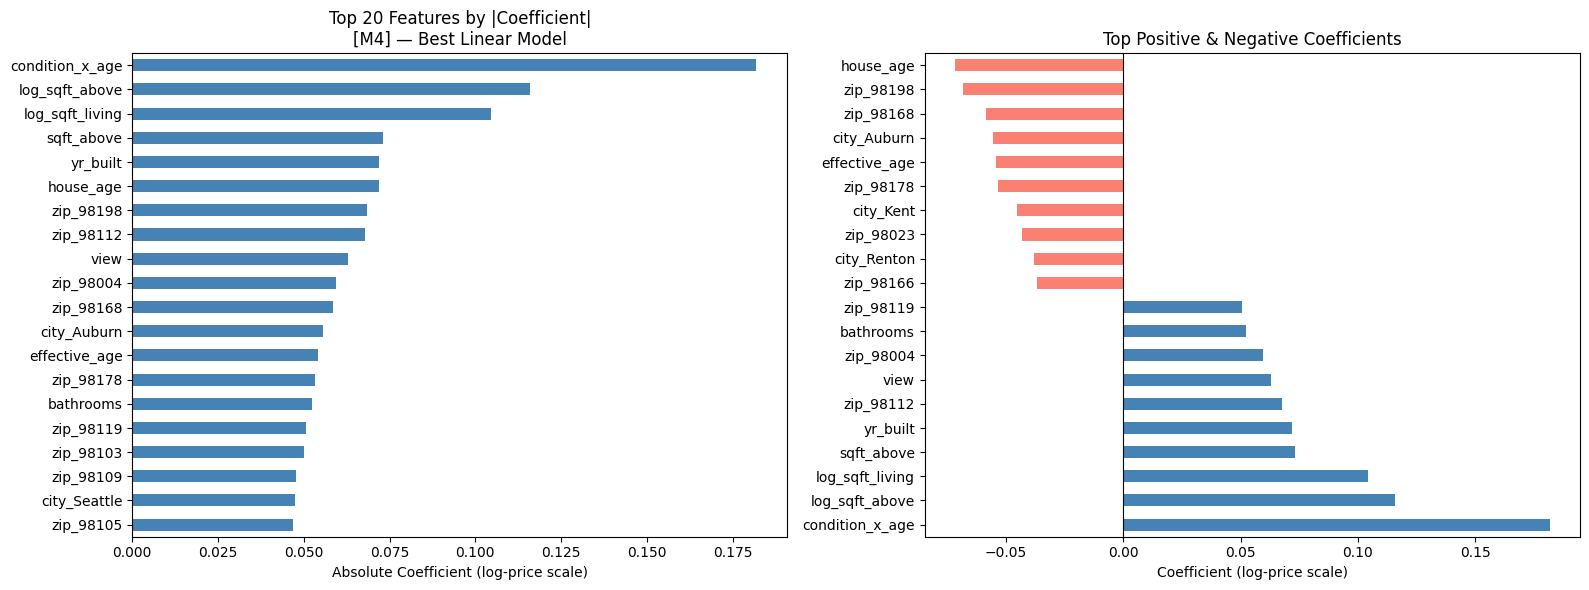

In [42]:
# Re-prep to get scaled feature names
X_best_tr_s, X_best_te_s = prep(best_X_tr, best_X_te)
best_model_obj.fit(X_best_tr_s, y_train)

coef = pd.Series(best_model_obj.coef_, index=feature_names)

# ── Top features by absolute coefficient ──
top_abs = coef.abs().sort_values(ascending=False).head(20)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: absolute magnitude
top_abs.plot(kind="barh", ax=axes[0], color="steelblue")
axes[0].invert_yaxis()
axes[0].set_title(f"Top 20 Features by |Coefficient|\n[{best_linear_id}] — Best Linear Model")
axes[0].set_xlabel("Absolute Coefficient (log-price scale)")

# Right: signed top/bottom 15
top_signed = pd.concat([coef.sort_values().head(10), coef.sort_values().tail(10)])
colors = ["salmon" if v < 0 else "steelblue" for v in top_signed]
top_signed.plot(kind="barh", ax=axes[1], color=colors)
axes[1].axvline(0, color="black", linewidth=0.8)
axes[1].invert_yaxis()
axes[1].set_title("Top Positive & Negative Coefficients")
axes[1].set_xlabel("Coefficient (log-price scale)")

plt.tight_layout()
plt.show()


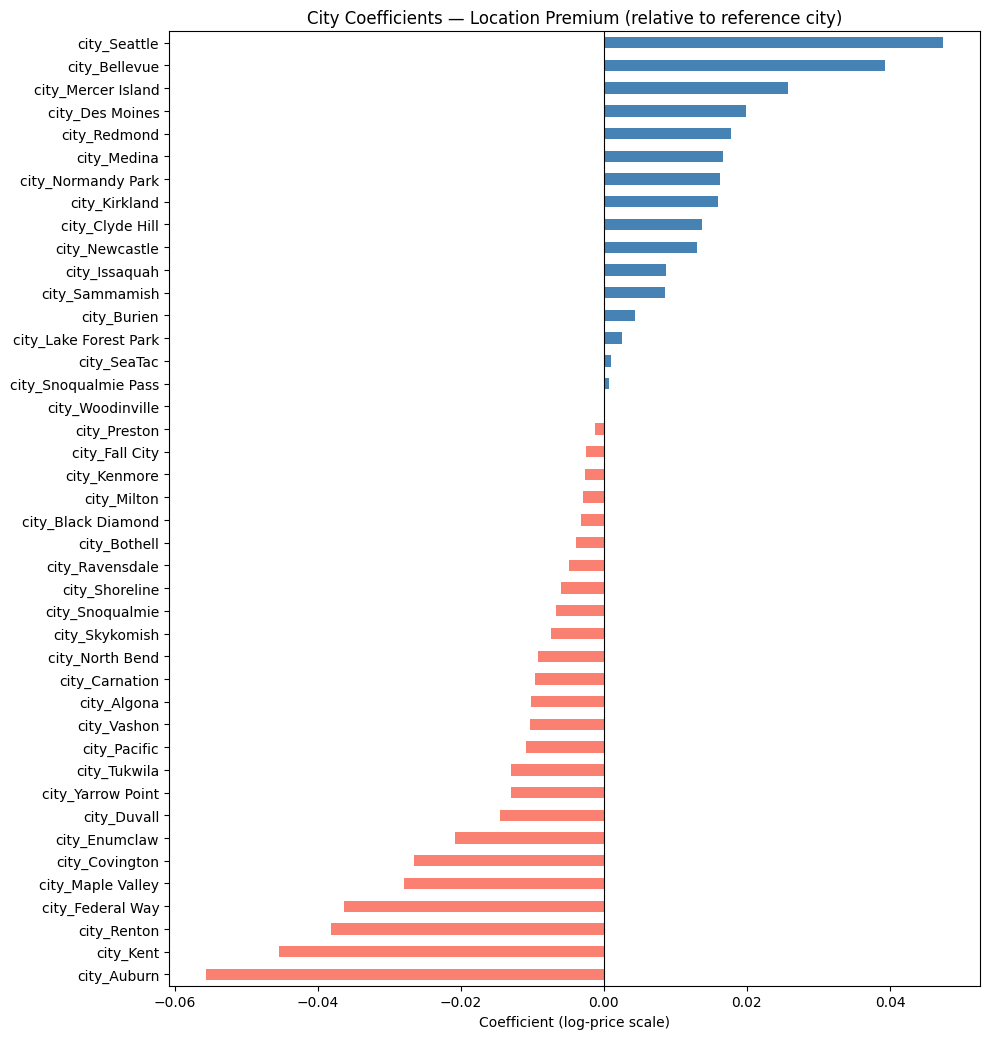

Top 5 premium cities: ['city_Seattle', 'city_Bellevue', 'city_Mercer Island', 'city_Des Moines', 'city_Redmond']
Bottom 5 cities: ['city_Maple Valley', 'city_Federal Way', 'city_Renton', 'city_Kent', 'city_Auburn']


In [43]:
# ── Location premium: city coefficients ──
city_coefs = coef[coef.index.str.startswith("city_")].sort_values(ascending=False)

if len(city_coefs) > 0:
    fig, ax = plt.subplots(figsize=(10, max(4, len(city_coefs) * 0.25)))
    city_coefs.plot(kind="barh", ax=ax, color=["steelblue" if v > 0 else "salmon" for v in city_coefs])
    ax.axvline(0, color="black", linewidth=0.8)
    ax.invert_yaxis()
    ax.set_title("City Coefficients — Location Premium (relative to reference city)")
    ax.set_xlabel("Coefficient (log-price scale)")
    plt.tight_layout()
    plt.show()
    print(f"Top 5 premium cities: {city_coefs.head(5).index.tolist()}")
    print(f"Bottom 5 cities: {city_coefs.tail(5).index.tolist()}")


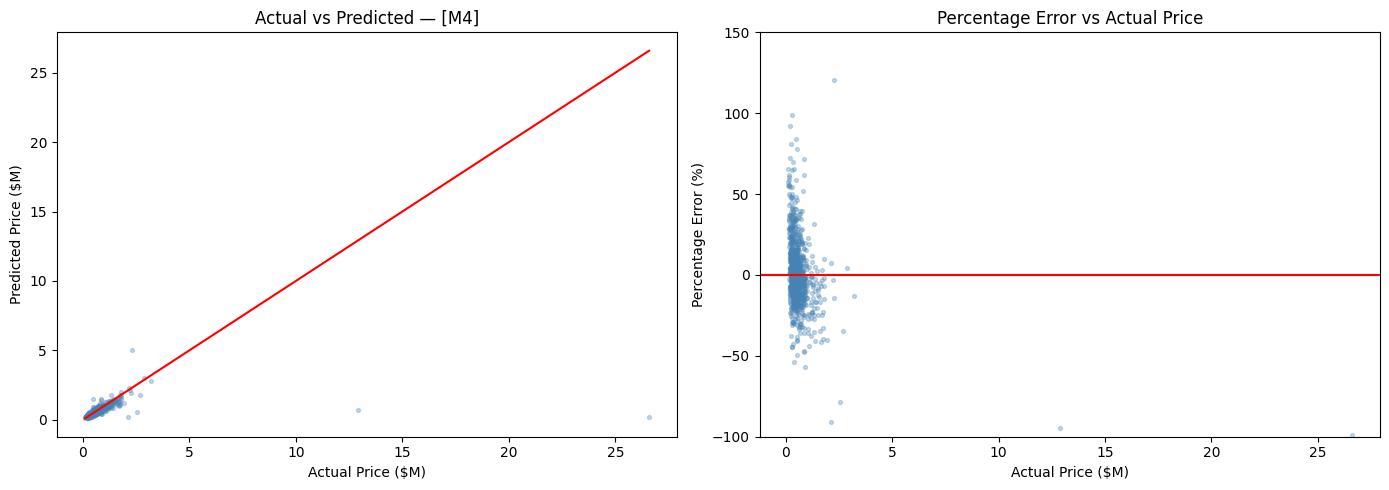


Final confirmed Test MAPE for [M4]: 15.24%


In [44]:
# ── Actual vs Predicted plot ──
best_te_pred = np.expm1(best_model_obj.predict(X_best_te_s))
best_te_actual = np.expm1(y_test)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Predicted vs actual
axes[0].scatter(best_te_actual / 1e6, best_te_pred / 1e6, alpha=0.3, s=8, color="steelblue")
mn = min(best_te_actual.min(), best_te_pred.min()) / 1e6
mx = max(best_te_actual.max(), best_te_pred.max()) / 1e6
axes[0].plot([mn, mx], [mn, mx], color="red", linewidth=1.5)
axes[0].set_xlabel("Actual Price ($M)")
axes[0].set_ylabel("Predicted Price ($M)")
axes[0].set_title(f"Actual vs Predicted — [{best_linear_id}]")

# Residual plot
pct_error = (best_te_pred - best_te_actual) / best_te_actual * 100
axes[1].scatter(best_te_actual / 1e6, pct_error, alpha=0.3, s=8, color="steelblue")
axes[1].axhline(0, color="red", linewidth=1.5)
axes[1].set_xlabel("Actual Price ($M)")
axes[1].set_ylabel("Percentage Error (%)")
axes[1].set_title("Percentage Error vs Actual Price")
axes[1].set_ylim(-100, 150)

plt.tight_layout()
plt.show()

final_mape = mean_absolute_percentage_error(best_te_actual, best_te_pred)
print(f"\nFinal confirmed Test MAPE for [{best_linear_id}]: {final_mape*100:.2f}%")


In [45]:
# ── Plain-language interpretation ──
print("=" * 65)
print("MODEL INTERPRETATION — WHAT DRIVES HOUSE PRICES?")
print("=" * 65)

# Size
size_coef = coef.get("log_sqft_living", coef.get("sqft_living", None))
if size_coef is not None:
    pct_effect = (np.exp(size_coef * 0.1) - 1) * 100
    print(f"\n1. SIZE (log_sqft_living coef = {size_coef:.3f})")
    print(f"   A 10% increase in living area raises predicted price by ~{pct_effect:.1f}%")

# Grade
grade_coef = coef.get("grade", None)
if grade_coef is not None:
    print(f"\n2. GRADE (coef = {grade_coef:.3f})")
    print(f"   One grade step up → {np.exp(grade_coef)*100-100:.1f}% price increase (holding all else equal)")

# Waterfront
wf_coef = coef.get("waterfront", None)
if wf_coef is not None:
    print(f"\n3. WATERFRONT (coef = {wf_coef:.3f})")
    print(f"   Waterfront location → {np.exp(wf_coef)*100-100:.1f}% price premium")

# Age
age_coef = coef.get("house_age", coef.get("effective_age", None))
if age_coef is not None:
    print(f"\n4. AGE (coef = {age_coef:.3f})")
    print(f"   Each additional year of age → {np.exp(age_coef)*100-100:.2f}% change in price")

print(f"\n5. LOCATION")
if len(city_coefs) > 0:
    top = city_coefs.head(1)
    bot = city_coefs.tail(1)
    print(f"   Highest-premium city: {top.index[0].replace('city_','')}  (coef = {top.iloc[0]:.3f})")
    print(f"   Lowest-premium city:  {bot.index[0].replace('city_','')}  (coef = {bot.iloc[0]:.3f})")
    spread = np.exp(top.iloc[0] - bot.iloc[0])
    print(f"   Price ratio top vs bottom city: {spread:.1f}x")
print("=" * 65)


MODEL INTERPRETATION — WHAT DRIVES HOUSE PRICES?

1. SIZE (log_sqft_living coef = 0.104)
   A 10% increase in living area raises predicted price by ~1.0%

3. WATERFRONT (coef = 0.032)
   Waterfront location → 3.2% price premium

4. AGE (coef = -0.072)
   Each additional year of age → -6.94% change in price

5. LOCATION
   Highest-premium city: Seattle  (coef = 0.047)
   Lowest-premium city:  Auburn  (coef = -0.056)
   Price ratio top vs bottom city: 1.1x
